In [1]:
import os
import glob
import hashlib
import numpy as np
from PIL import Image

recon_dir = "/data/akherandish3/Statistical_OOD_detection/results_patches_ddad_native/samples_001/ddad_native_0_4/inpainting/recon"

# Example target directory to compare against (change this to your actual target)
# e.g., original images or a previous run's output
target_dir = "/data/akheirandish3/mvtec_ad/cable/test/combined"

def get_file_hash(filepath):
    """Calculate the MD5 hash of a file to check for exact byte-level changes."""
    with open(filepath, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def calculate_mse(imageA_path, imageB_path):
    """Calculate the Mean Squared Error between two images to detect pixel changes."""
    try:
        imgA = np.array(Image.open(imageA_path).convert('RGB')).astype("float")
        imgB = np.array(Image.open(imageB_path).convert('RGB')).astype("float")
        err = np.sum((imgA - imgB) ** 2)
        err /= float(imgA.shape[0] * imgA.shape[1])
        return err
    except Exception as e:
        return str(e)

recon_files = sorted(glob.glob(os.path.join(recon_dir, "*.png")))

print(f"Found {len(recon_files)} images in the recon directory.\n")

for recon_path in recon_files:
    filename = os.path.basename(recon_path)
    recon_hash = get_file_hash(recon_path)
    
    # Check if a file with the same name exists in the target directory
    target_path = os.path.join(target_dir, filename)
    
    if os.path.exists(target_path):
        target_hash = get_file_hash(target_path)
        mse_diff = calculate_mse(recon_path, target_path)
        
        if recon_hash == target_hash:
            print(f"[{filename}] NO CHANGES: Exact same file (Hash matched).")
        else:
            print(f"[{filename}] CHANGED: Hash differs. Pixel MSE difference: {mse_diff:.2f}")
    else:
        print(f"[{filename}] Target file for comparison not found (Hash: {recon_hash[:8]}...)")

Found 20 images in the recon directory.

[0_0_00000.png] Target file for comparison not found (Hash: 69f2f59e...)
[10_0_00000.png] Target file for comparison not found (Hash: b196592d...)
[11_0_00000.png] Target file for comparison not found (Hash: 31677a40...)
[12_0_00000.png] Target file for comparison not found (Hash: 42c11905...)
[13_0_00000.png] Target file for comparison not found (Hash: 122c0801...)
[14_0_00000.png] Target file for comparison not found (Hash: d486a1ee...)
[15_0_00000.png] Target file for comparison not found (Hash: fe877886...)
[16_0_00000.png] Target file for comparison not found (Hash: bd1d587c...)
[17_0_00000.png] Target file for comparison not found (Hash: 464e7962...)
[18_0_00000.png] Target file for comparison not found (Hash: b9cb1111...)
[19_0_00000.png] Target file for comparison not found (Hash: ac3255cd...)
[1_0_00000.png] Target file for comparison not found (Hash: 29de8e8b...)
[2_0_00000.png] Target file for comparison not found (Hash: f8b1f9c6...)


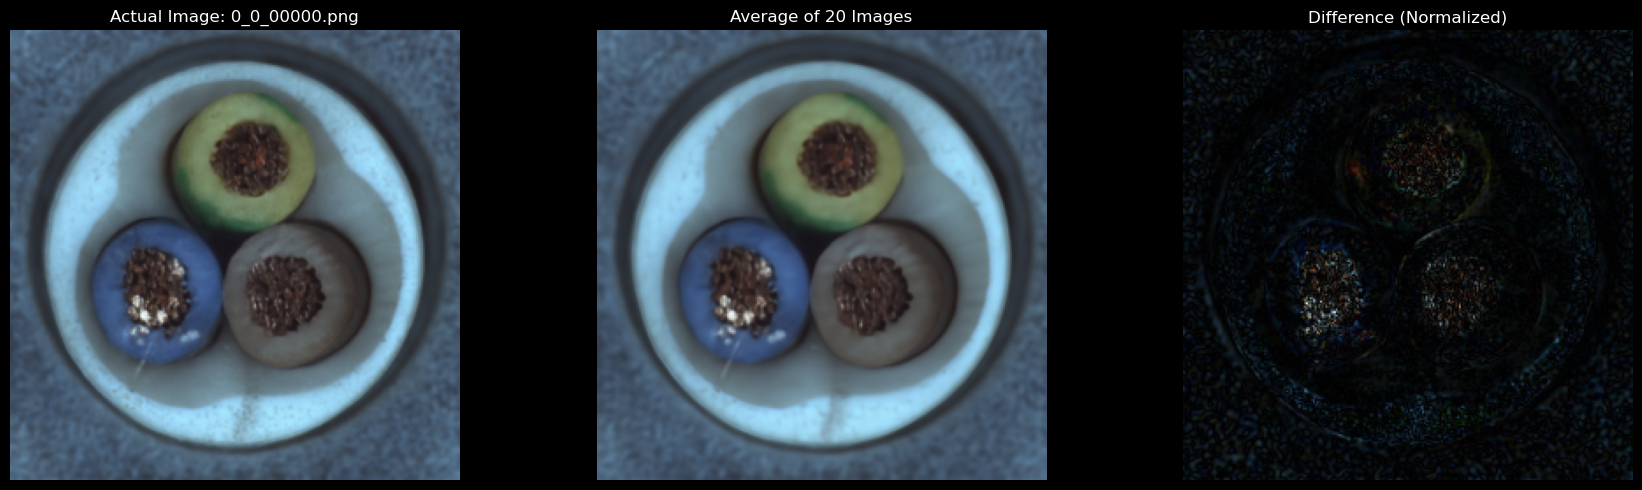

In [4]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

recon_dir = "/data/akherandish3/Statistical_OOD_detection/results_patches_ddad_native/samples_001/ddad_native_0_4/inpainting/recon"
recon_files = sorted(glob.glob(os.path.join(recon_dir, "*.png")))

# Load all 20 images into a numpy array
images = []
for file_path in recon_files:
    img = np.array(Image.open(file_path).convert('RGB')).astype("float")
    images.append(img)
    
images = np.array(images)

# Calculate the average image across all 20 images
average_image = np.mean(images, axis=0)

# Pick one actual image for the example (e.g., the first one)
sample_idx = 0
actual_image = images[sample_idx]
sample_filename = os.path.basename(recon_files[sample_idx])

# Calculate the absolute difference between the actual image and the average image
diff_image = np.abs(actual_image - average_image)

# Normalize the difference image so it's easier to see the variations
diff_normalized = (diff_image - diff_image.min()) / (diff_image.max() - diff_image.min() + 1e-8)

# Plot the actual image, the average image, and their difference
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.title(f"Actual Image: {sample_filename}")
plt.imshow(actual_image.astype("uint8"))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Average of 20 Images")
plt.imshow(average_image.astype("uint8"))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Difference (Normalized)")
plt.imshow(diff_normalized)
plt.axis('off')

plt.tight_layout()
plt.show()

In [1]:
import json
import argparse
import numpy as np

parser = argparse.ArgumentParser()
# parser.add_argument('--json_path', type=str, default='/data/akherandish3/Statistical_OOD_detection/results_eval_ddad_native_faces/faces_random.json')
# parser.add_argument('--json_path', type=str, default='/data/akherandish3/Statistical_OOD_detection/results_eval_ddad_native_faces/CT_scan.json')
parser.add_argument('--json_path', type=str, default='/data/akherandish3/Statistical_OOD_detection/results_eval_ddad_native_CT_pca_16_resnet_101_autoEncoder_CT/ae_pixel_autoencoder_CT_same_data_CT_scan.json')

# ./results_eval_ddad_native_faces/CT_scan.json
args = parser.parse_args(args=[])

with open(args.json_path, 'r') as f:
    data = json.load(f)

per_sample = data.get('per_sample', {})

# if not per_sample:
#     print("No samples found in JSON.")
#     return

# Collect metrics
metrics = {"raw": {"px_roc_auc": [], "snr": []}, "sigma_5.0": {"px_roc_auc": [], "snr": []}}

for sample_k, sample_v in per_sample.items():
    for sigma_k in ['raw', 'sigma_5.0']:
        if sigma_k in sample_v:
            metrics[sigma_k]['px_roc_auc'].append(sample_v[sigma_k].get('px_roc_auc', np.nan))
            metrics[sigma_k]['snr'].append(sample_v[sigma_k].get('snr', np.nan))

print(f"--- Averages computed over {len(per_sample)} samples ---")
for sigma_k in ['raw', 'sigma_5.0']:
    avg_auc = np.nanmean(metrics[sigma_k]['px_roc_auc'])
    avg_snr = np.nanmean(metrics[sigma_k]['snr'])
    print(f"[{sigma_k}]")
    print(f"  Average Pixel AUC : {avg_auc:.6f}")
    print(f"  Average SNR       : {avg_snr:.6f}")

--- Averages computed over 100 samples ---
[raw]
  Average Pixel AUC : 0.680904
  Average SNR       : 0.813257
[sigma_5.0]
  Average Pixel AUC : 0.722100
  Average SNR       : 0.964469
